# Zone J Before/After Retirement Comparison

This notebook compares the same zone-J first-contingency screening before and after the `Gowanus*` / `Narrows*` retirement edit.

It uses the same helper logic as `zone_j_worst_24h.ipynb`, with the first contingency fixed to the same thermal unit in both cases.

Important limitation:
- the `after retirement` run is a full-year 2019 baseline
- the `before retirement` results currently available on disk only cover a single 24-hour case on `2019-01-01`

So this notebook gives you two comparison modes:
1. a direct overlap comparison on the hours both runs actually contain
2. a side-by-side summary of each run's top-ranked 24-hour window

Only the overlap comparison is apples-to-apples with the current data. A fully comparable before/after ranking across all of 2019 still requires a full-year pre-retirement baseline run.

One more caution: `stress_score` and `window_score` are normalized screening scores built separately inside each run. Use them to rank hours or windows **within** a run, but do not compare their raw magnitudes directly across runs.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

NOTEBOOK_DIR = Path.cwd().resolve()
if not (NOTEBOOK_DIR / "zone_j_worst_24h.py").exists():
    NOTEBOOK_DIR = Path("/home/fs01/jl2966/nygrid2sienna_baseline_after_retire/analysis")

if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

import zone_j_worst_24h as zj

pd.options.display.float_format = "{:,.3f}".format
plt.style.use("seaborn-v0_8-whitegrid")

AFTER_BASE_DIR = Path("/home/fs01/jl2966/nygrid2sienna_baseline_after_retire")
AFTER_RESULTS_RELATIVE = Path("baseline_after_retire") / "baseline_after_retire" / "results"

BEFORE_BASE_DIR = Path("/home/fs01/jl2966/nygrid2sienna")
BEFORE_RESULTS_RELATIVE = Path("baseline_before_retire_full_year") / "baseline_before_retire_full_year" / "results"


ZONE = "J"
WINDOW_HOURS = 24

after_context = zj.get_zone_context(AFTER_BASE_DIR, zone=ZONE)
before_context = zj.get_zone_context(BEFORE_BASE_DIR, zone=ZONE)

# Hold the first contingency fixed across both runs.
TARGET_UNIT = after_context["biggest_zone_thermal"]
assert TARGET_UNIT in before_context["zone_thermal_names"]

print(f"Zone: {ZONE}")
print(f"First contingency unit used in both runs: {TARGET_UNIT}")
print(f"After-retirement repo: {AFTER_BASE_DIR}")
print(f"Before-retirement repo: {BEFORE_BASE_DIR}")


Zone: J
First contingency unit used in both runs: Ravenswood ST 02
After-retirement repo: /home/fs01/jl2966/nygrid2sienna_baseline_after_retire
Before-retirement repo: /home/fs01/jl2966/nygrid2sienna


In [2]:
before_hourly = zj.build_hourly_metrics(
    BEFORE_BASE_DIR,
    zone=ZONE,
    contingency_unit=TARGET_UNIT,
    results_relative=BEFORE_RESULTS_RELATIVE,
)
after_hourly = zj.build_hourly_metrics(
    AFTER_BASE_DIR,
    zone=ZONE,
    contingency_unit=TARGET_UNIT,
    results_relative=AFTER_RESULTS_RELATIVE,
)

before_windows = zj.rank_windows(before_hourly, window_hours=WINDOW_HOURS)
after_windows = zj.rank_windows(after_hourly, window_hours=WINDOW_HOURS)

common_hours = before_hourly.index.intersection(after_hourly.index)
before_overlap = before_hourly.loc[common_hours].copy()
after_overlap = after_hourly.loc[common_hours].copy()

coverage = pd.DataFrame(
    [
        {
            "run": "before_retirement",
            "hour_count": len(before_hourly),
            "start": before_hourly.index.min(),
            "end": before_hourly.index.max(),
            "top_window_start": before_windows.iloc[0]["window_start"] if not before_windows.empty else pd.NaT,
            "top_window_end": before_windows.iloc[0]["window_end"] if not before_windows.empty else pd.NaT,
        },
        {
            "run": "after_retirement",
            "hour_count": len(after_hourly),
            "start": after_hourly.index.min(),
            "end": after_hourly.index.max(),
            "top_window_start": after_windows.iloc[0]["window_start"] if not after_windows.empty else pd.NaT,
            "top_window_end": after_windows.iloc[0]["window_end"] if not after_windows.empty else pd.NaT,
        },
    ]
)
display(coverage)

if len(before_hourly) != len(after_hourly):
    display(Markdown(
        f"**Warning:** the before-retirement data only has **{len(before_hourly)}** hours, while the after-retirement run has **{len(after_hourly)}** hours. "
        "Use the overlap comparison below as the strict before/after comparison, and treat the side-by-side top-window ranking as a context comparison only."
    ))


,run,hour_count,start,end,top_window_start,top_window_end
0,before_retirement,8760,2019-01-01,2019-12-31 23:00:00,2019-02-01 06:00:00,2019-02-02 05:00:00
1,after_retirement,8760,2019-01-01,2019-12-31 23:00:00,2019-02-01 06:00:00,2019-02-02 05:00:00


In [3]:
top_window_compare = pd.concat(
    {
        "before_retirement": before_windows.head(5).reset_index(drop=True),
        "after_retirement": after_windows.head(5).reset_index(drop=True),
    },
    axis=1,
)

display(
    top_window_compare[[
        ("before_retirement", "window_start"),
        ("before_retirement", "window_end"),
        ("before_retirement", "window_score"),
        ("before_retirement", "mean_zone_j_load_mw"),
        ("before_retirement", "mean_contingency_unit_dispatch_mw"),
        ("before_retirement", "mean_if10_utilization"),
        ("before_retirement", "mean_zone_j_hvdc_abs_utilization"),
        ("before_retirement", "min_zone_j_thermal_headroom_mw"),
        ("after_retirement", "window_start"),
        ("after_retirement", "window_end"),
        ("after_retirement", "window_score"),
        ("after_retirement", "mean_zone_j_load_mw"),
        ("after_retirement", "mean_contingency_unit_dispatch_mw"),
        ("after_retirement", "mean_if10_utilization"),
        ("after_retirement", "mean_zone_j_hvdc_abs_utilization"),
        ("after_retirement", "min_zone_j_thermal_headroom_mw"),
    ]]
)

print("Interpretation: these are the top-ranked 24h windows within each run separately.")
print("Because the available before-retirement run is only one day long, its top-ranked window is necessarily that one day.")
print("Do not compare raw window_score magnitudes across runs; they are run-normalized ranking scores.")


before_retirement                                                       \
         window_start          window_end window_score mean_zone_j_load_mw   
0 2019-02-01 06:00:00 2019-02-02 05:00:00      614.435          13,753.051   
1 2019-02-01 07:00:00 2019-02-02 06:00:00      614.426          13,649.771   
2 2019-02-01 08:00:00 2019-02-02 07:00:00      563.059          13,526.324   
3 2019-02-01 00:00:00 2019-02-01 23:00:00      544.274          14,161.717   
4 2019-02-01 01:00:00 2019-02-02 00:00:00      543.460          14,102.337   

                                                           \
  mean_contingency_unit_dispatch_mw mean_if10_utilization   
0                           182.669                 0.845   
1                           182.669                 0.852   
2                           154.113                 0.864   
3                           142.068                 0.858   
4                           142.068                 0.855   

                                                                   \
  mean_zone_j_hvdc_abs_utilization min_zone_j_thermal_headroom_mw   
0                            1.000                      1,715.000   
1                            1.000                      1,715.000   
2                            1.000                      1,715.000   
3                            1.000                      1,715.000   
4                            1.000                      1,715.000   

     after_retirement                                                       \
         window_start          window_end window_score mean_zone_j_load_mw   
0 2019-02-01 06:00:00 2019-02-02 05:00:00      671.104          13,753.051   
1 2019-02-01 07:00:00 2019-02-02 06:00:00      671.087          13,649.771   
2 2019-02-01 08:00:00 2019-02-02 07:00:00      621.841          13,526.324   
3 2019-02-01 00:00:00 2019-02-01 23:00:00      606.654          14,161.717   
4 2019-02-01 01:00:00 2019-02-02 00:00:00      606.066          14,102.337   

                                                           \
  mean_contingency_unit_dispatch_mw mean_if10_utilization   
0                           240.420                 0.844   
1                           240.420                 0.850   
2                           209.797                 0.864   
3                           198.886                 0.858   
4                           198.886                 0.859   

                                                                   
  mean_zone_j_hvdc_abs_utilization min_zone_j_thermal_headroom_mw  
0                            1.000                        763.000  
1                            1.000                        763.000  
2                            1.000                        763.000  
3                            1.000                        763.000  
4                            1.000                        763.000

Interpretation: these are the top-ranked 24h windows within each run separately.
Because the available before-retirement run is only one day long, its top-ranked window is necessarily that one day.
Do not compare raw window_score magnitudes across runs; they are run-normalized ranking scores.


In [4]:
overlap_summary = pd.DataFrame(
    [
        {
            "metric": "zone_j_load_mw",
            "before_mean": before_overlap["zone_j_load_mw"].mean(),
            "after_mean": after_overlap["zone_j_load_mw"].mean(),
            "after_minus_before": after_overlap["zone_j_load_mw"].mean() - before_overlap["zone_j_load_mw"].mean(),
        },
        {
            "metric": "contingency_unit_dispatch_mw",
            "before_mean": before_overlap["contingency_unit_dispatch_mw"].mean(),
            "after_mean": after_overlap["contingency_unit_dispatch_mw"].mean(),
            "after_minus_before": after_overlap["contingency_unit_dispatch_mw"].mean() - before_overlap["contingency_unit_dispatch_mw"].mean(),
        },
        {
            "metric": "if10_utilization",
            "before_mean": before_overlap["if10_utilization"].mean(),
            "after_mean": after_overlap["if10_utilization"].mean(),
            "after_minus_before": after_overlap["if10_utilization"].mean() - before_overlap["if10_utilization"].mean(),
        },
        {
            "metric": "zone_j_hvdc_abs_utilization",
            "before_mean": before_overlap["zone_j_hvdc_abs_utilization"].mean(),
            "after_mean": after_overlap["zone_j_hvdc_abs_utilization"].mean(),
            "after_minus_before": after_overlap["zone_j_hvdc_abs_utilization"].mean() - before_overlap["zone_j_hvdc_abs_utilization"].mean(),
        },
        {
            "metric": "zone_j_storage_soc_frac",
            "before_mean": before_overlap["zone_j_storage_soc_frac"].mean(),
            "after_mean": after_overlap["zone_j_storage_soc_frac"].mean(),
            "after_minus_before": after_overlap["zone_j_storage_soc_frac"].mean() - before_overlap["zone_j_storage_soc_frac"].mean(),
        },
        {
            "metric": "zone_j_thermal_headroom_mw",
            "before_mean": before_overlap["zone_j_thermal_headroom_mw"].mean(),
            "after_mean": after_overlap["zone_j_thermal_headroom_mw"].mean(),
            "after_minus_before": after_overlap["zone_j_thermal_headroom_mw"].mean() - before_overlap["zone_j_thermal_headroom_mw"].mean(),
        },
    ]
)

display(overlap_summary)
print(f"Common hours compared directly: {len(common_hours)}")
print(f"Overlap period: {common_hours.min()} to {common_hours.max()}")


,metric,before_mean,after_mean,after_minus_before
0,zone_j_load_mw,"7,486.106","7,486.106",0.000
1,contingency_unit_dispatch_mw,3.492,3.650,0.158
2,if10_utilization,0.621,0.625,0.004
3,zone_j_hvdc_abs_utilization,0.965,0.964,-0.001
4,zone_j_storage_soc_frac,0.317,0.313,-0.003
5,zone_j_thermal_headroom_mw,"7,719.651","6,701.438","-1,018.213"


Common hours compared directly: 8760
Overlap period: 2019-01-01 00:00:00 to 2019-12-31 23:00:00


In [5]:
overlap_detail = pd.DataFrame(index=common_hours)
for metric in [
    "zone_j_load_mw",
    "contingency_unit_dispatch_mw",
    "if10_utilization",
    "zone_j_hvdc_abs_utilization",
    "zone_j_storage_soc_frac",
    "zone_j_thermal_headroom_mw",
]:
    overlap_detail[f"before_{metric}"] = before_overlap[metric]
    overlap_detail[f"after_{metric}"] = after_overlap[metric]
    overlap_detail[f"delta_{metric}"] = after_overlap[metric] - before_overlap[metric]

display(overlap_detail.head(24))


,before_zone_j_load_mw,after_zone_j_load_mw,delta_zone_j_load_mw,before_contingency_unit_dispatch_mw,after_contingency_unit_dispatch_mw,delta_contingency_unit_dispatch_mw,before_if10_utilization,after_if10_utilization,delta_if10_utilization,before_zone_j_hvdc_abs_utilization,after_zone_j_hvdc_abs_utilization,delta_zone_j_hvdc_abs_utilization,before_zone_j_storage_soc_frac,after_zone_j_storage_soc_frac,delta_zone_j_storage_soc_frac,before_zone_j_thermal_headroom_mw,after_zone_j_thermal_headroom_mw,delta_zone_j_thermal_headroom_mw
DateTime,,,,,,,,,,,,,,,,,,
2019-01-01 00:00:00,"5,855.764","5,855.764",0.000,3.000,3.000,0.000,0.895,0.184,-0.711,1.000,1.000,0.000,0.458,0.592,0.134,"8,011.700","6,997.700","-1,014.000"
2019-01-01 01:00:00,"5,481.845","5,481.845",0.000,3.000,3.000,0.000,0.980,0.975,-0.006,1.000,1.000,0.000,0.416,0.550,0.134,"8,011.700","6,997.700","-1,014.000"
2019-01-01 02:00:00,"5,286.820","5,286.820",0.000,3.000,3.000,0.000,0.269,1.274,1.005,1.000,1.000,0.000,0.534,0.477,-0.057,"8,011.700","6,997.700","-1,014.000"
2019-01-01 03:00:00,"5,209.858","5,209.858",0.000,3.000,3.000,0.000,0.409,0.403,-0.006,1.000,1.000,0.000,0.570,0.513,-0.057,"8,011.700","6,997.700","-1,014.000"
2019-01-01 04:00:00,"5,268.966","5,268.966",0.000,3.000,3.000,0.000,0.378,1.253,0.876,1.000,1.000,0.000,0.606,0.441,-0.165,"8,011.700","6,997.700","-1,014.000"
2019-01-01 05:00:00,"5,523.723","5,523.723",0.000,3.000,3.000,0.000,0.089,0.322,0.233,1.000,1.000,0.000,0.695,0.557,-0.138,"8,011.700","6,997.700","-1,014.000"
2019-01-01 06:00:00,"6,197.643","6,197.643",0.000,3.000,3.000,0.000,0.219,0.811,0.591,1.000,1.000,0.000,0.698,0.515,-0.183,"8,011.700","6,997.700","-1,014.000"
2019-01-01 07:00:00,"6,782.156","6,782.156",0.000,3.000,3.000,0.000,0.682,0.330,-0.352,1.000,1.000,0.000,0.656,0.599,-0.057,"8,011.700","6,997.700","-1,014.000"
2019-01-01 08:00:00,"7,097.707","7,097.707",0.000,3.000,3.000,0.000,0.012,1.196,1.184,1.000,1.000,0.000,0.692,0.484,-0.207,"8,011.700","6,997.700","-1,014.000"


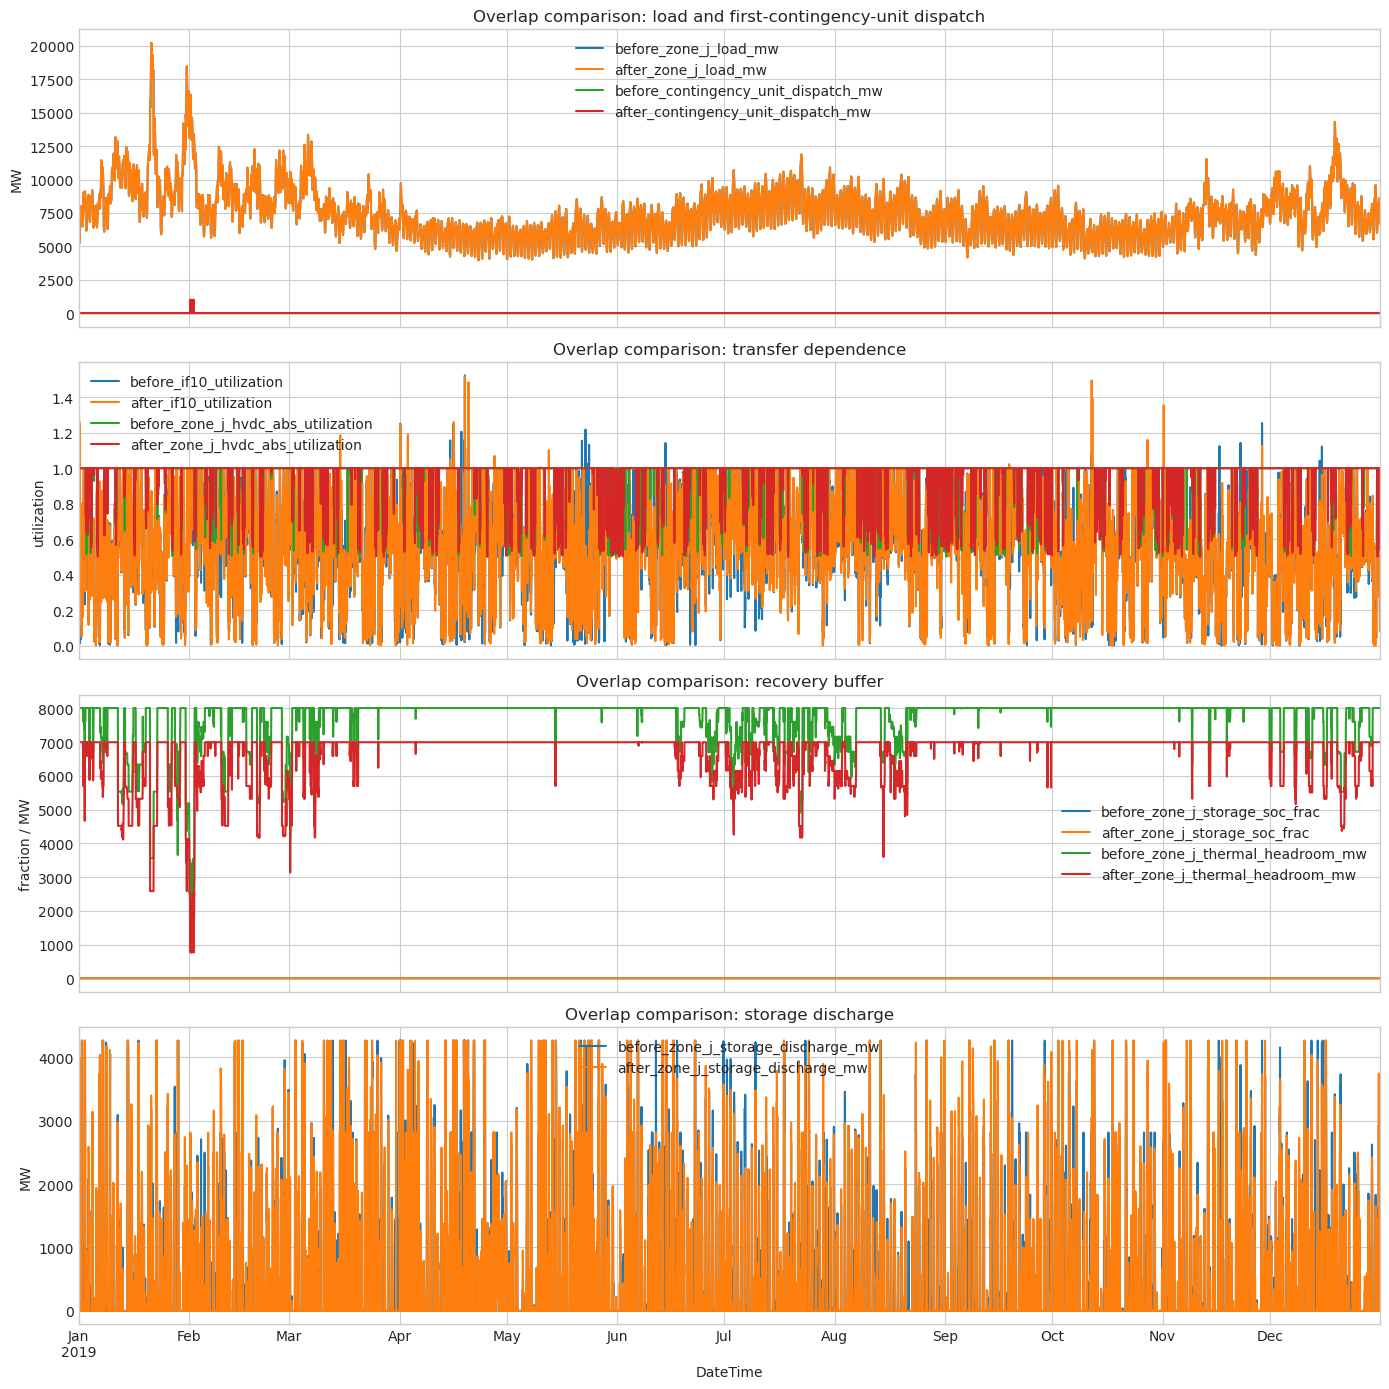

In [6]:
fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)

plot_df = pd.DataFrame(index=common_hours)
plot_df["before_zone_j_load_mw"] = before_overlap["zone_j_load_mw"]
plot_df["after_zone_j_load_mw"] = after_overlap["zone_j_load_mw"]
plot_df["before_contingency_unit_dispatch_mw"] = before_overlap["contingency_unit_dispatch_mw"]
plot_df["after_contingency_unit_dispatch_mw"] = after_overlap["contingency_unit_dispatch_mw"]
plot_df[["before_zone_j_load_mw", "after_zone_j_load_mw", "before_contingency_unit_dispatch_mw", "after_contingency_unit_dispatch_mw"]].plot(ax=axes[0])
axes[0].set_title("Overlap comparison: load and first-contingency-unit dispatch")
axes[0].set_ylabel("MW")

plot_df = pd.DataFrame(index=common_hours)
plot_df["before_if10_utilization"] = before_overlap["if10_utilization"]
plot_df["after_if10_utilization"] = after_overlap["if10_utilization"]
plot_df["before_zone_j_hvdc_abs_utilization"] = before_overlap["zone_j_hvdc_abs_utilization"]
plot_df["after_zone_j_hvdc_abs_utilization"] = after_overlap["zone_j_hvdc_abs_utilization"]
plot_df.plot(ax=axes[1])
axes[1].set_title("Overlap comparison: transfer dependence")
axes[1].set_ylabel("utilization")

plot_df = pd.DataFrame(index=common_hours)
plot_df["before_zone_j_storage_soc_frac"] = before_overlap["zone_j_storage_soc_frac"]
plot_df["after_zone_j_storage_soc_frac"] = after_overlap["zone_j_storage_soc_frac"]
plot_df["before_zone_j_thermal_headroom_mw"] = before_overlap["zone_j_thermal_headroom_mw"]
plot_df["after_zone_j_thermal_headroom_mw"] = after_overlap["zone_j_thermal_headroom_mw"]
plot_df.plot(ax=axes[2])
axes[2].set_title("Overlap comparison: recovery buffer")
axes[2].set_ylabel("fraction / MW")

plot_df = pd.DataFrame(index=common_hours)
plot_df["before_zone_j_storage_discharge_mw"] = before_overlap["zone_j_storage_discharge_mw"]
plot_df["after_zone_j_storage_discharge_mw"] = after_overlap["zone_j_storage_discharge_mw"]
plot_df.plot(ax=axes[3])
axes[3].set_title("Overlap comparison: storage discharge")
axes[3].set_ylabel("MW")
axes[3].set_xlabel("DateTime")

plt.tight_layout()


In [7]:
before_nonthermal = zj.rank_nonthermal_candidates(
    BEFORE_BASE_DIR,
    before_windows.iloc[0]["window_start"],
    before_windows.iloc[0]["window_end"],
    zone=ZONE,
    results_relative=BEFORE_RESULTS_RELATIVE,
)
after_nonthermal = zj.rank_nonthermal_candidates(
    AFTER_BASE_DIR,
    after_windows.iloc[0]["window_start"],
    after_windows.iloc[0]["window_end"],
    zone=ZONE,
    results_relative=AFTER_RESULTS_RELATIVE,
)

display(pd.concat({"before_retirement": before_nonthermal, "after_retirement": after_nonthermal}, axis=1))
print("Interpretation: this compares the strongest non-thermal second-contingency candidates inside each run's own top-ranked 24h window.")


before_retirement                                                            \
               name mean_flow_mw mean_abs_flow_mw peak_abs_flow_mw asset_type   
0               HTP      660.000          660.000          660.000       hvdc   
1               VFT      660.000          660.000          660.000       hvdc   
2             IF_10    3,673.912        3,673.912        4,350.000  interface   
3             IF_11     -515.000          515.000          515.000  interface   

                                                        after_retirement  \
  capacity_mw mean_abs_utilization peak_abs_utilization             name   
0     660.000                1.000                1.000              HTP   
1     660.000                1.000                1.000              VFT   
2   4,350.000                0.845                1.000            IF_10   
3   1,293.000                0.398                0.398            IF_11   

                                                                         \
  mean_flow_mw mean_abs_flow_mw peak_abs_flow_mw asset_type capacity_mw   
0      660.000          660.000          660.000       hvdc     660.000   
1      660.000          660.000          660.000       hvdc     660.000   
2    3,670.223        3,670.223        4,350.000  interface   4,350.000   
3     -515.000          515.000          515.000  interface   1,293.000   

                                             
  mean_abs_utilization peak_abs_utilization  
0                1.000                1.000  
1                1.000                1.000  
2                0.844                1.000  
3                0.398                0.398

Interpretation: this compares the strongest non-thermal second-contingency candidates inside each run's own top-ranked 24h window.
